In [1]:
# import required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pprint import pprint
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn import preprocessing
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.model_selection import KFold
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from imblearn.over_sampling import SMOTE

In [2]:
#Install the ucimlrepo package
!pip install ucimlrepo

# 1.  Importing the dataset

In [3]:
from ucimlrepo import fetch_ucirepo
dataset = fetch_ucirepo(id=275)

In [4]:
# Accessing features
X = dataset.data.features
y = dataset.data.targets

X = X.drop('dteday', axis=1)

display(X.head())
display(y.head())

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0


,cnt
0,16
1,40
2,32
3,13
4,1


# 2. Splitting the dataset (70-15-15)%

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (12165, 12), (12165, 1)
Validation set shape: (2607, 12), (2607, 1)
Test set shape: (2607, 12), (2607, 1)


In [6]:
# Fixing categorical features
categorical_features = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

X_train_encoded = preprocessor.fit_transform(X_train)

X_val_encoded = preprocessor.transform(X_val)
X_test_encoded = preprocessor.transform(X_test)

print("One-hot encoding applied successfully:")
print(f"Training set shape after encoding: {X_train_encoded.shape}")
print(f"Validation set shape after encoding: {X_val_encoded.shape}")
print(f"Test set shape after encoding: {X_test_encoded.shape}")

One-hot encoding applied successfully:
Training set shape after encoding: (12165, 61)
Validation set shape after encoding: (2607, 61)
Test set shape after encoding: (2607, 61)


# 3. Implementing a decision tree regressor from scratch

In [8]:
class DecisionTreeRegressor:
    class Node:
        def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
            self.feature_index = feature_index
            self.threshold = threshold
            self.left = left
            self.right = right
            self.value = value

    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.root = None

    def _mse(self, y):
        if len(y) == 0:
            return 0
        mean = np.mean(y)
        return np.mean((y - mean) ** 2)

    def _mse_reduction(self, y, y_left, y_right):
        mse_parent = self._mse(y)
        mse_left = self._mse(y_left)
        mse_right = self._mse(y_right)

        n_parent = len(y)
        n_left = len(y_left)
        n_right = len(y_right)

        weighted_mse_children = (n_left / n_parent) * mse_left + (n_right / n_parent) * mse_right
        return mse_parent - weighted_mse_children

    def _find_best_split(self, X, y):
        best_reduction = -float('inf')
        best_feature_index = None
        best_threshold = None

        n_samples, n_features = X.shape

        for feature_index in range(n_features):
            thresholds = np.unique(X[:, feature_index])
            for threshold in thresholds:
                y_left = y[X[:, feature_index] <= threshold]
                y_right = y[X[:, feature_index] > threshold]

                if len(y_left) < self.min_samples_leaf or len(y_right) < self.min_samples_leaf:
                    continue

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                reduction = self._mse_reduction(y, y_left, y_right)

                if reduction > best_reduction:
                    best_reduction = reduction
                    best_feature_index = feature_index
                    best_threshold = threshold

        return best_feature_index, best_threshold

    def _build_tree(self, X, y, depth):
        n_samples = len(y)

        node_value = np.mean(y) if len(y) > 0 else 0

        if (self.max_depth is not None and depth >= self.max_depth) or \
           n_samples < self.min_samples_split or \
           len(np.unique(y)) == 1:
            return self.Node(value=node_value)

        best_feature_index, best_threshold = self._find_best_split(X, y)

        if best_feature_index is None:
             return self.Node(value=node_value)

        left_indices = X[:, best_feature_index] <= best_threshold
        right_indices = X[:, best_feature_index] > best_threshold

        X_left, y_left = X[left_indices], y[left_indices]
        X_right, y_right = X[right_indices], y[right_indices]

        left_subtree = self._build_tree(X_left, y_left, depth + 1)
        right_subtree = self._build_tree(X_right, y_right, depth + 1)

        return self.Node(feature_index=best_feature_index, threshold=best_threshold,
                         left=left_subtree, right=right_subtree)

    def fit(self, X, y):
        y = y.values.flatten() if isinstance(y, pd.DataFrame) else np.array(y)
        X = X.toarray() if hasattr(X, 'toarray') else np.array(X)

        self.root = self._build_tree(X, y, depth=0)

    def _predict_single(self, x, node):
        if node.value is not None:
            return node.value

        if x[node.feature_index] <= node.threshold:
            return self._predict_single(x, node.left)
        else:
            return self._predict_single(x, node.right)

    def predict(self, X):
        X = X.toarray() if hasattr(X, 'toarray') else np.array(X)
        return np.array([self._predict_single(x, self.root) for x in X])

# 4. Hyperparameter Tuning

In [9]:
param_grid = {
    'max_depth': list(range(10, 19)),
    'min_samples_split': list(range(7, 13)),
    'min_samples_leaf': list(range(2, 8))
}

display(param_grid)

{'max_depth': [10, 11, 12, 13, 14, 15, 16, 17, 18],
 'min_samples_split': [7, 8, 9, 10, 11, 12],
 'min_samples_leaf': [2, 3, 4, 5, 6, 7]}

In [10]:
# Initializing variables to keep track of the best hyperparameters
best_mse = float('inf')
best_params = {}

In [11]:
# Continuing with the grid search loop
for max_depth in param_grid['max_depth']:
    for min_samples_split in param_grid['min_samples_split']:
        for min_samples_leaf in param_grid['min_samples_leaf']:
            print(f"Testing params: max_depth={max_depth}, min_samples_split={min_samples_split}, min_samples_leaf={min_samples_leaf}")

            dt_regressor = DecisionTreeRegressor(max_depth=max_depth,
                                                 min_samples_split=min_samples_split,
                                                 min_samples_leaf=min_samples_leaf)

            # Training the model
            dt_regressor.fit(X_train_encoded, y_train)

            y_val_pred = dt_regressor.predict(X_val_encoded)

            # Calculating MSE
            mse = mean_squared_error(y_val, y_val_pred)
            print(f"Validation MSE: {mse}")

            if mse < best_mse:
                best_mse = mse
                best_params = {
                    'max_depth': max_depth,
                    'min_samples_split': min_samples_split,
                    'min_samples_leaf': min_samples_leaf
                }

Testing params: max_depth=10, min_samples_split=7, min_samples_leaf=2
Validation MSE: 9069.087286743174
Testing params: max_depth=10, min_samples_split=7, min_samples_leaf=3
Validation MSE: 8934.216236802884
Testing params: max_depth=10, min_samples_split=7, min_samples_leaf=4
Validation MSE: 8997.79888570349
Testing params: max_depth=10, min_samples_split=7, min_samples_leaf=5
Validation MSE: 8901.597234062856
Testing params: max_depth=10, min_samples_split=7, min_samples_leaf=6
Validation MSE: 8991.481118511216
Testing params: max_depth=10, min_samples_split=7, min_samples_leaf=7
Validation MSE: 8985.359723902393
Testing params: max_depth=10, min_samples_split=8, min_samples_leaf=2
Validation MSE: 9049.758571732045
Testing params: max_depth=10, min_samples_split=8, min_samples_leaf=3
Validation MSE: 8922.103126723792
Testing params: max_depth=10, min_samples_split=8, min_samples_leaf=4
Validation MSE: 8997.79888570349
Testing params: max_depth=10, min_samples_split=8, min_samples_lea

In [12]:
print("Best hyperparameters found:")
display(best_params)
print(f"Best Validation MSE: {best_mse}")

Best hyperparameters found:


{'max_depth': 18, 'min_samples_split': 12, 'min_samples_leaf': 3}

Best Validation MSE: 5101.238320800519


# 5. Performance evaluation using best hyperparameters

In [13]:
final_dt_regressor = DecisionTreeRegressor(
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf']
)

final_dt_regressor.fit(X_train_encoded, y_train)
y_test_pred = final_dt_regressor.predict(X_test_encoded)

test_r2 = r2_score(y_test, y_test_pred)
print(f"R-squared on the test set: {test_r2}")

R-squared on the test set: 0.8293332904921711


# 6. Reporting MSE and showing scatter plot

In [14]:
test_mse = mean_squared_error(y_test, y_test_pred)
print(f"Mean Squared Error on the test set: {test_mse}")

Mean Squared Error on the test set: 5257.273061479488


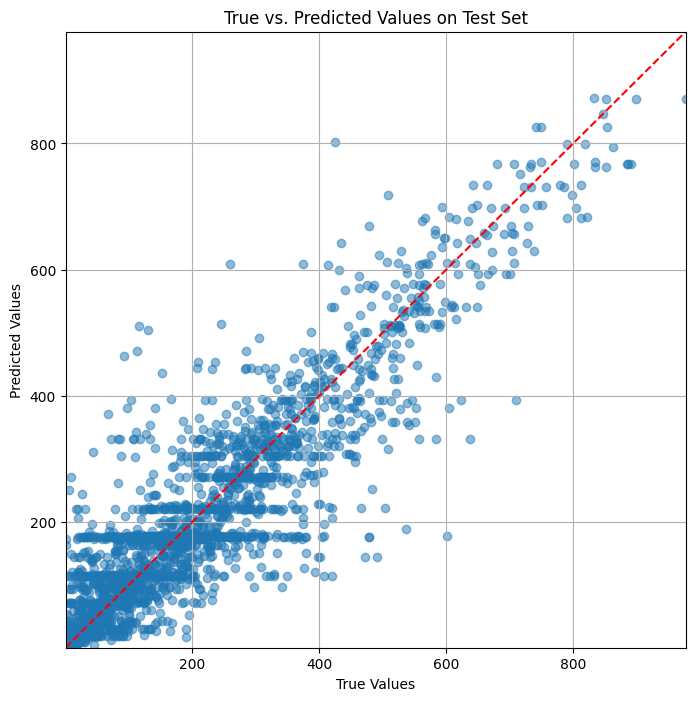

In [15]:
y_test_np = y_test.values.flatten()

plt.figure(figsize=(8, 8))
plt.scatter(y_test_np, y_test_pred, alpha=0.5)

min_val = min(y_test_np.min(), y_test_pred.min())
max_val = max(y_test_np.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs. Predicted Values on Test Set")

plt.grid(True)

plt.xlim([min_val, max_val])
plt.ylim([min_val, max_val])

plt.show()

# 7. Fitting scikit learn's decision tree regressor model on the training set

In [16]:
from sklearn.tree import DecisionTreeRegressor
sklearn_dt_regressor = DecisionTreeRegressor()

In [17]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=sklearn_dt_regressor,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42), # Using 5-fold cross-validation
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

In [18]:
# Finding best hyperparameters
grid_search.fit(X_train_encoded, y_train)
print("Best hyperparameters found by GridSearchCV:")
display(grid_search.best_params_)

print(f"Best cross-validation score (negative MSE): {grid_search.best_score_}")

best_cv_mse = -grid_search.best_score_
print(f"Best cross-validation MSE: {best_cv_mse}")

Best hyperparameters found by GridSearchCV:


{'max_depth': 18, 'min_samples_leaf': 2, 'min_samples_split': 10}

Best cross-validation score (negative MSE): -5867.584014432455
Best cross-validation MSE: 5867.584014432455


# 8. Performance evaluation of scikit learn model using best hyperparameters

In [19]:
best_sklearn_regressor = grid_search.best_estimator_
y_test_pred_sklearn = best_sklearn_regressor.predict(X_test_encoded)

test_r2_sklearn = r2_score(y_test, y_test_pred_sklearn)
print(f"R-squared on the test set (scikit-learn): {test_r2_sklearn}")

R-squared on the test set (scikit-learn): 0.8305656649904688


# 9. Reporting MSE and showing scatter plot for Scikit learn model

In [20]:
test_mse_sklearn = mean_squared_error(y_test, y_test_pred_sklearn)
print(f"Mean Squared Error on the test set (scikit-learn): {test_mse_sklearn}")

Mean Squared Error on the test set (scikit-learn): 5219.310594925591


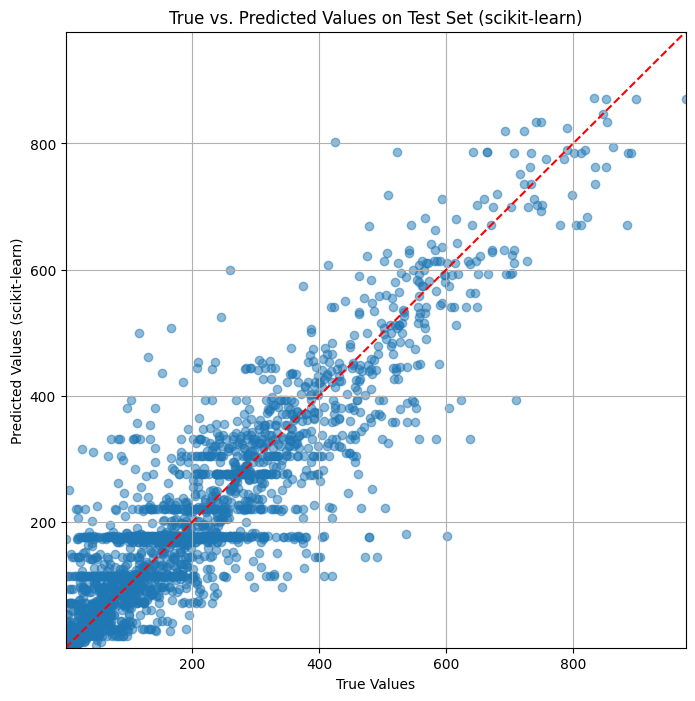

In [21]:
y_test_np = y_test.values.flatten()

plt.figure(figsize=(8, 8))
plt.scatter(y_test_np, y_test_pred_sklearn, alpha=0.5)

min_val = min(y_test_np.min(), y_test_pred_sklearn.min())
max_val = max(y_test_np.max(), y_test_pred_sklearn.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel("True Values")
plt.ylabel("Predicted Values (scikit-learn)")
plt.title("True vs. Predicted Values on Test Set (scikit-learn)")

plt.grid(True)

plt.xlim([min_val, max_val])
plt.ylim([min_val, max_val])

plt.show()

# 10. Visualization of the scikit learn dicision tree regressor

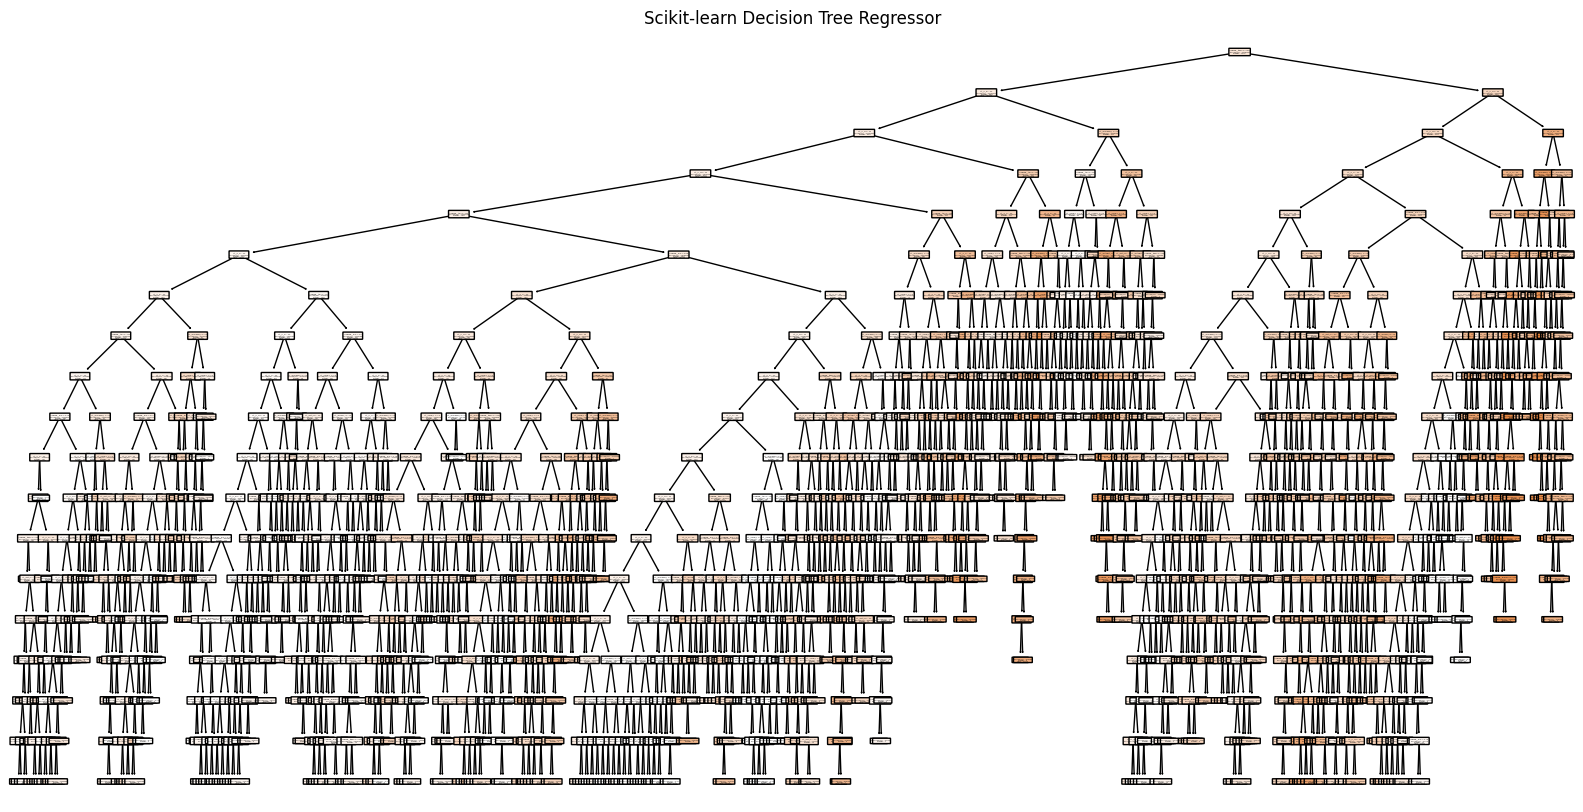

In [22]:
encoded_feature_names = preprocessor.get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(best_sklearn_regressor, filled=True, rounded=True, feature_names=encoded_feature_names)
plt.title("Scikit-learn Decision Tree Regressor")
plt.show()

## 11. Comparison of From-Scratch and Scikit-learn Decision Tree Regressors

In [39]:
print("--- Best Hyperparameters ---\n")
print(" "*20, "max depth |", "min samples for split |", "min samples for leaf node")
print("_"*90,"\n")
print(f"custom              :    {best_params['max_depth']}    |           {best_params['min_samples_split']}          |             {best_params['min_samples_leaf']}")
print("_"*90,"\n")
print(f"Scikit-learn        :    {grid_search.best_params_['max_depth']}    |           {grid_search.best_params_['min_samples_split']}          |             {grid_search.best_params_['min_samples_leaf']} ")
print("\n")

print("--- Test Set Prediction Performance ---\n")
print(f"From Scratch MSE: {test_mse:.2f}")
print(f"Scikit-learn MSE: {test_mse_sklearn:.2f}")
print(f"From Scratch R-squared: {test_r2:.4f}")
print(f"Scikit-learn R-squared: {test_r2_sklearn:.4f}")
print("\n")

tolerance = 50
r2_tolerance = 0.01

mse_close = abs(test_mse - test_mse_sklearn) < tolerance
r2_close = abs(test_r2 - test_r2_sklearn) < r2_tolerance

print("--- Closeness Check ---\n")
print(f"MSE values are close (within {tolerance}): {mse_close}")
print(f"R-squared values are close (within {r2_tolerance}): {r2_close}")

--- Best Hyperparameters ---

                     max depth | min samples for split | min samples for leaf node
__________________________________________________________________________________________ 

custom              :    18    |           12          |             3
__________________________________________________________________________________________ 

Scikit-learn        :    18    |           10          |             2 


--- Test Set Prediction Performance ---

From Scratch MSE: 5257.27
Scikit-learn MSE: 5219.31
From Scratch R-squared: 0.8293
Scikit-learn R-squared: 0.8306


--- Closeness Check ---

MSE values are close (within 50): True
R-squared values are close (within 0.01): True
